In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
data = pd.read_excel('data/online_retail_II.xlsx')
data.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
86630,497473,85099B,JUMBO BAG RED WHITE SPOTTY,6,2010-02-09 15:27:00,1.95,13156.0,United Kingdom
395836,527380,22415,WHITE TISSUE REAM,1,2010-10-17 12:52:00,7.95,14953.0,United Kingdom
481928,534518,21121,SET/10 RED POLKADOT PARTY CANDLES,24,2010-11-23 12:01:00,1.25,16155.0,United Kingdom
68614,495443,21078,SET/20 STRAWBERRY PAPER NAPKINS,4,2010-01-25 11:53:00,0.85,NaN,United Kingdom
301372,518752,22646,CERAMIC STRAWBERRY CAKE MONEY BANK,36,2010-08-11 12:39:00,1.45,17716.0,United Kingdom


In [3]:
# 1.entender el dataset 
# 1.1 revisar en cuentas lugares esta el supermercado 
paises = data["Country"].unique()
print("paises -> ", paises)
print(f"Total de paises : {len(paises)}")

paises ->  ['United Kingdom' 'France' 'USA' 'Belgium' 'Australia' 'EIRE' 'Germany'
 'Portugal' 'Japan' 'Denmark' 'Nigeria' 'Netherlands' 'Poland' 'Spain'
 'Channel Islands' 'Italy' 'Cyprus' 'Greece' 'Norway' 'Austria' 'Sweden'
 'United Arab Emirates' 'Finland' 'Switzerland' 'Unspecified' 'Malta'
 'Bahrain' 'RSA' 'Bermuda' 'Hong Kong' 'Singapore' 'Thailand' 'Israel'
 'Lithuania' 'West Indies' 'Lebanon' 'Korea' 'Brazil' 'Canada' 'Iceland']
Total de paises : 40


Text(0.5, 1.0, 'Distribucion de paises')

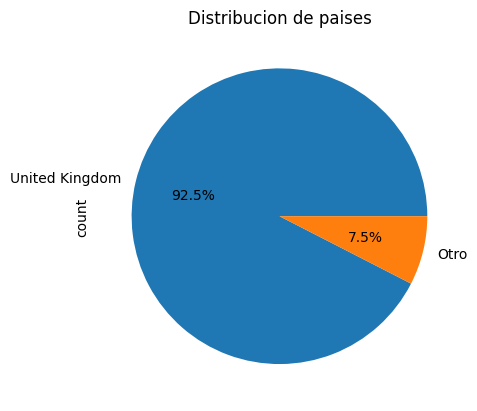

In [4]:
# Agrupar ciudades que no sea U.K como otros 
data_c = data.copy()
data_c.loc[data_c['Country']!='United Kingdom','Country'] = 'Otro'

((data_c.Country.value_counts() / data_c.shape[0])*100).plot(kind='pie',autopct='%1.1f%%')
plt.title("Distribucion de paises")

comentarios : como el 92.5% de los datos corresponden a U.K, solamente nos centraremos en las ventas, clientes y productos de este sitio

In [5]:
# seleccion del df para el U.K 
df = data[data.Country == 'United Kingdom'].copy()
print(f"total de datos en el dataframe de UK : {df.shape}")

total de datos en el dataframe de UK : (485852, 8)


In [6]:
# revision de valores nulos 
(df.isnull().sum() / df.shape[0]) * 100

Invoice         0.000000
StockCode       0.000000
Description     0.602653
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    21.905642
Country         0.000000
dtype: float64

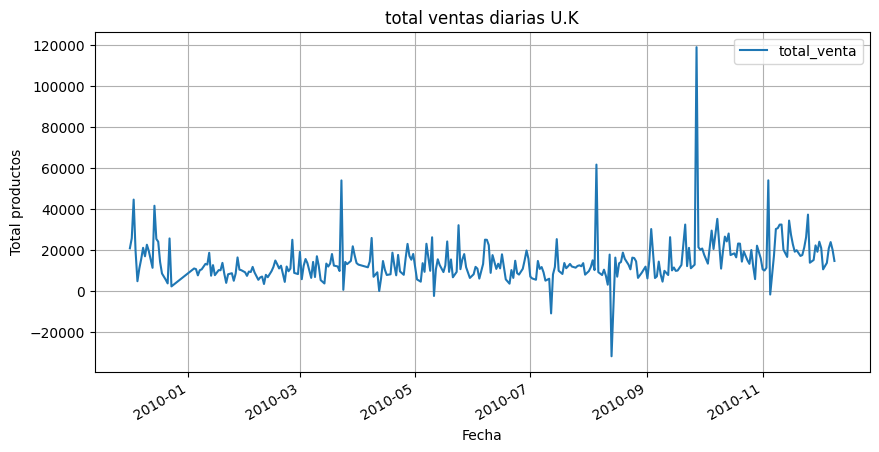

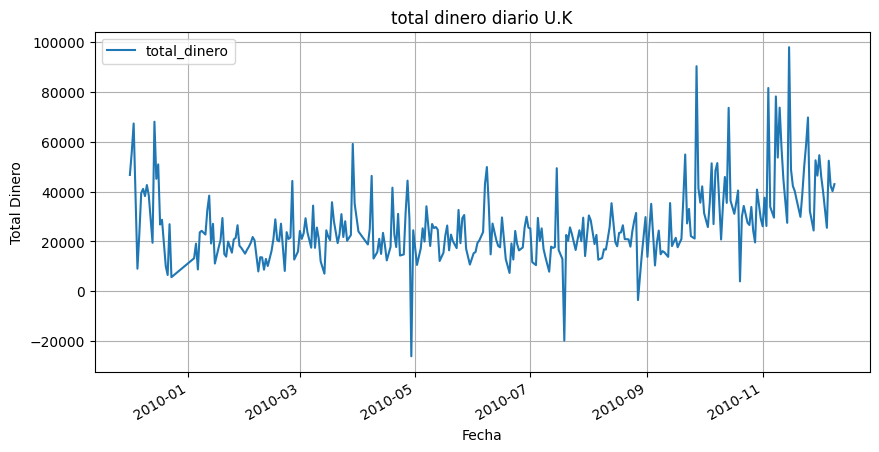

In [9]:
# 2.1 Revisar total productos ventas
# Normalizar fecha (eliminar hora)
df['fecha_norm'] = df['InvoiceDate'].dt.normalize()

# Agrupar por fecha y sumar total de productos vendidos
agrupado_fecha = (
    df.groupby('fecha_norm')
      .agg(total_venta=('Quantity', 'sum'))
      .reset_index()
      .set_index('fecha_norm')
).plot(figsize=(10,5))
plt.title(f'total productos vendidos diarias U.K')
plt.grid()
plt.xlabel("Fecha")
plt.ylabel("Total productos")
plt.show()

# 2.2. Revisar total dinero
df["TotalPrice"] = df.Quantity * df.Price

agrupado_dinero = (
    df.groupby('fecha_norm')
      .agg(total_dinero=('TotalPrice', 'sum'))
      .reset_index()
      .set_index('fecha_norm')
).plot(figsize=(10,5))
plt.title(f'total dinero diario U.K')
plt.grid()
plt.xlabel("Fecha")
plt.ylabel("Total Dinero")
plt.show()

<Axes: title={'center': 'Promedio ventas por hora'}, xlabel='hora'>

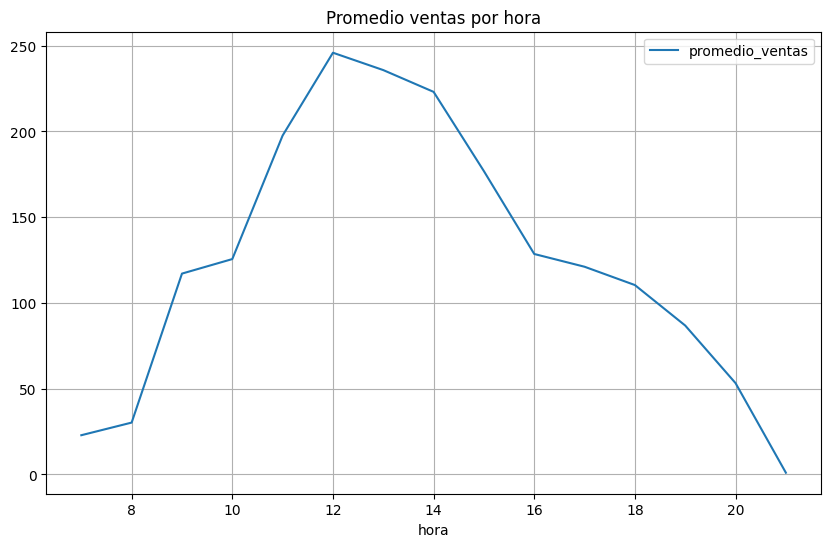

In [37]:
# 3. Revisar promedio de ventas por dia y hora. 

#3.1. Obtener hora 
df['hora'] = df["InvoiceDate"].dt.hour

# 3.2. obtener total ventas por cliente 
_ = df.groupby(['fecha_norm','hora']).agg(
    total_ventas = ('Invoice','count')
)

# 3.3 promedio ventas x horas 
promedio_ventas_horas = _.groupby(['hora']).agg(
    promedio_ventas = ('total_ventas', 'mean')
)

promedio_ventas_horas.plot(kind='line',figsize=(10,6),grid=True,title="Promedio ventas por hora")

In [38]:
promedio_ventas_horas

,promedio_ventas
hora,
7,22.866667
8,30.232044
9,117.094118
10,125.566775
11,197.593443
12,245.875817
13,235.751634
14,223.052117
15,176.820261
